# Images are arrays: MNIST with NumPy

MNIST is a classic dataset of handwritten digits: 60,000 training images and 10,000 test images, each labelled with the digit it shows. Every image is a 28×28 grid of numbers, so a set of images is a NumPy array, and everything you do to images (scaling, adding noise, shifting, cropping) is array manipulation.

This is the solution of [the exercises](mnist_numpy.ipynb). Where an exercise has more than one reasonable solution, the alternatives are compared.

## Loading MNIST

The images come from the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database). Its authors scaled each black-and-white digit to fit a 20×20 box, keeping its proportions, which smoothed the edges into grey levels. Then they placed it in a 28×28 frame with its centre of mass at the centre. Remember the 20×20 box: you will find it again when you crop the digits.

The dataset is downloaded as one `.npz` file, a zip of several NumPy arrays, from the address Keras uses. Its SHA-256 checksum is compared with the published one, so a corrupted download is detected. The file is kept in a `data/` folder that git ignores, so it is downloaded only once.

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

import numpy as np

MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_SHA256 = "731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1"

type Split = tuple[np.ndarray, np.ndarray]


def load_mnist(cache_dir: Path = Path("data")) -> tuple[Split, Split]:
    cache_dir.mkdir(exist_ok=True)
    path = cache_dir / "mnist.npz"
    if not path.exists():
        urllib.request.urlretrieve(MNIST_URL, path)
    if hashlib.sha256(path.read_bytes()).hexdigest() != MNIST_SHA256:
        path.unlink()
        raise ValueError("The download is corrupted and has been deleted: run the cell again")
    with np.load(path) as mnist:
        return (mnist["x_train"], mnist["y_train"]), (mnist["x_test"], mnist["y_test"])


(X_train, y_train), (X_test, y_test) = load_mnist()

`X_train` holds the training images and `y_train` their labels. A capital `X` for the inputs and a lowercase `y` for the targets is the usual convention in machine learning.

In [ ]:
type(X_train), X_train.dtype, X_train.shape

(numpy.ndarray, dtype('uint8'), (60000, 28, 28))

A NumPy array of 60,000 images of 28×28 pixels: three dimensions. Its type is `uint8`, an unsigned 8-bit integer, so every pixel is an integer from 0 to 255, where 0 is the background and 255 the darkest ink. At one byte per pixel, the whole training set takes about 47 MB.

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

The labels are the digits 0 to 9, one per image. The first image, as numbers:

In [ ]:
def print_pixel_values(image: np.ndarray) -> None:
    for row in image:
        print("".join(f"{pixel:4}" for pixel in row))


print_pixel_values(X_train[0])

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

and drawn with matplotlib:

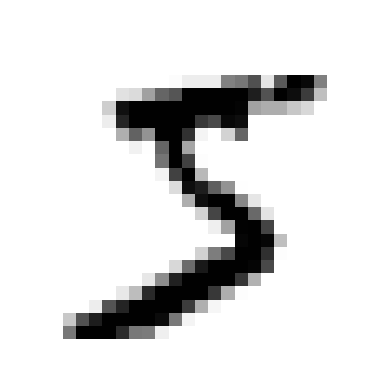

In [ ]:
import matplotlib.pyplot as plt


def plot_image(image: np.ndarray) -> None:
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


plot_image(X_train[0])

The colour map decides how numbers become colours. With `cmap="binary"`, 0 is drawn white and 255 black, like ink on paper; with `cmap="gray"`, the same array shows a white digit on a black background. The array doesn't change, only its picture.

In [ ]:
y_train[0]

np.uint8(5)

The first 100 training images:

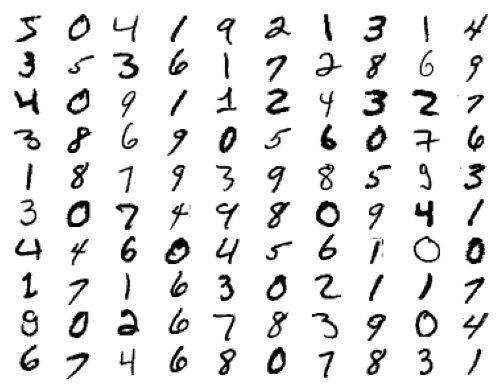

In [ ]:
def plot_first_100(images: np.ndarray) -> None:
    for index, image in enumerate(images[:100]):
        plt.subplot(10, 10, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


plot_first_100(X_train)

## Exercises

### Shapes and indexing

**1.** Create `matrix_first_100_labels`, a 10×10 array with the first 100 labels, and display it. It should match the grid of images above.

In [ ]:
matrix_first_100_labels = y_train[:100].reshape(10, 10)
matrix_first_100_labels

array([[5, 0, 4, 1, 9, 2, 1, 3, 1, 4],
       [3, 5, 3, 6, 1, 7, 2, 8, 6, 9],
       [4, 0, 9, 1, 1, 2, 4, 3, 2, 7],
       [3, 8, 6, 9, 0, 5, 6, 0, 7, 6],
       [1, 8, 7, 9, 3, 9, 8, 5, 9, 3],
       [3, 0, 7, 4, 9, 8, 0, 9, 4, 1],
       [4, 4, 6, 0, 4, 5, 6, 1, 0, 0],
       [1, 7, 1, 6, 3, 0, 2, 1, 1, 7],
       [9, 0, 2, 6, 7, 8, 3, 9, 0, 4],
       [6, 7, 4, 6, 8, 0, 7, 8, 3, 1]], dtype=uint8)

`reshape` doesn't copy anything here: it returns a *view* of the same 100 numbers, read as 10 rows of 10.

**2.** Many models expect each example as one flat row of numbers. Create `X_train_flat` and `X_test_flat`, with shapes 60,000×784 and 10,000×784.

In [ ]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
X_train_flat.shape, X_test_flat.shape

((60000, 784), (10000, 784))

`-1` asks NumPy to work out that dimension: 28 × 28 = 784. Flattening loses no pixel: row `r`, column `c` of an image becomes position `28 * r + c` of its row, and `reshape(-1, 28, 28)` gives the images back. What the flat row loses is the *neighbourhood*: nothing in it says that position 29 is right below position 1. Convolutional networks keep the 2D shape for this reason.

**3.** Change `plot_image` so that it accepts both a 28×28 image and a flat row of 784 pixels. Check it with `X_train_flat[0]`.

In [ ]:
def plot_image(image: np.ndarray) -> None:
    if image.ndim == 1:
        side = int(np.sqrt(image.size))
        image = image.reshape(side, side)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

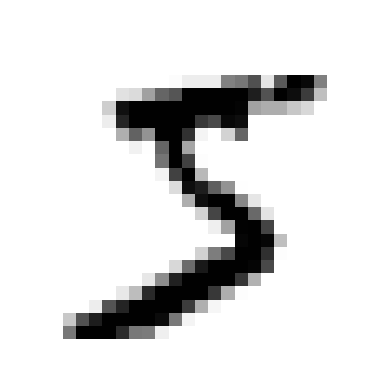

In [ ]:
plot_image(X_train_flat[0])

Computing the side from the size, instead of writing 28, makes the function work for any square image. The square root of a perfect square is exact in floating point, so `int` gives 28; for a size that isn't a perfect square, `reshape` fails with a clear error, which is the right behaviour.

**4.** Check, with one expression and no loop, that the bottom-right pixel is 0 in every training image.

In [ ]:
np.all(X_train[:, -1, -1] == 0)

np.True_

`X_train[:, -1, -1]` selects the last row and the last column of every image at once: 60,000 values.

**5.** Does any digit touch the edge of its frame? Store in `n_touching_border` the number of training images with ink (a non-zero pixel) in their first or last row or column.

In [ ]:
border = np.zeros((28, 28), dtype=bool)
border[[0, -1], :] = True
border[:, [0, -1]] = True

n_touching_border = int(X_train[:, border].any(axis=1).sum())
n_touching_border

813

A boolean mask of shape 28×28 selects the same 108 border pixels of every image: `X_train[:, border]` has shape 60,000×108. The same count without a mask:

In [ ]:
touches_border = (
    X_train[:, 0, :].any(axis=1)
    | X_train[:, -1, :].any(axis=1)
    | X_train[:, :, 0].any(axis=1)
    | X_train[:, :, -1].any(axis=1)
)
int(touches_border.sum())

813

Centring by the centre of mass pushes 813 digits, about 1.4% of them, against an edge. Keep it in mind for the shift exercises: those digits have no room to move in some directions.

### Data types

**6.** Compute `X_train[0] + X_train[0]` and look at its maximum. Then compute the same sum correctly, and store in `n_overflowed_pixels` the number of pixels where the two results differ. Why do they differ?

In [ ]:
doubled_uint8 = X_train[0] + X_train[0]
doubled_uint8.max()

np.uint8(254)

In [ ]:
doubled = X_train[0].astype(np.int32) + X_train[0]
n_overflowed_pixels = int((doubled_uint8 != doubled).sum())
doubled.max(), n_overflowed_pixels

(np.int32(510), 111)

A `uint8` holds 0 to 255. When a result doesn't fit, NumPy doesn't warn: it keeps the result modulo 256, so 200 + 200 = 400 becomes 144. Every pixel of 128 or more overflows. Converting to a wider type first (`astype`) avoids it, and so does dividing by 255 first, which gives floats. The same trap appears whenever you do arithmetic on images.

### One-hot encoding

**7.** Some models expect each label as a *one-hot* vector: ten numbers, all 0 except a 1 at the position of the digit. Label 5 becomes `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`. Create `y_train_onehot` and `y_test_onehot`.

In [ ]:
y_train_onehot = np.zeros((len(y_train), 10))
y_train_onehot[np.arange(len(y_train)), y_train] = 1
y_train_onehot[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

Indexing with two arrays selects one element per pair: row `i`, column `y_train[i]`. A shorter way:

In [ ]:
y_test_onehot = np.eye(10)[y_test]
y_test_onehot[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

`np.eye(10)` is the 10×10 identity matrix, whose row `k` is exactly the one-hot vector of `k`, so indexing it with the labels picks one row per label.

### Normalisation and standardisation

**8.** Display the minimum, maximum, mean and standard deviation of the pixels of the training images.

In [ ]:
X_train.min(), X_train.max(), X_train.mean(), X_train.std()

(np.uint8(0),
 np.uint8(255),
 np.float64(33.318421449829934),
 np.float64(78.56748998339798))

**9.** Scale the training images to the range [0, 1] as `X_train_norm`, of type `float32`, and plot its first image.

In [ ]:
X_train_norm = X_train.astype(np.float32) / 255
X_train_norm.dtype, X_train_norm.min(), X_train_norm.max()

(dtype('float32'), np.float32(0.0), np.float32(1.0))

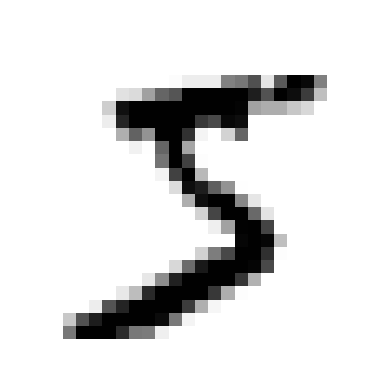

In [ ]:
plot_image(X_train_norm[0])

Dividing by 255 works because the range of the pixels is known in advance. The general *min-max* formula, `(X - X.min()) / (X.max() - X.min())`, gives the same result here, since the minimum is 0 and the maximum 255. `float32` takes half the memory of NumPy's default `float64`, and it is the type neural networks use. The picture doesn't change: `imshow` maps the smallest and largest values to the ends of the colour map.

**10.** Store in `pixel_norm_mean` and `pixel_norm_std` the mean and the standard deviation of the pixels of `X_train_norm`. You will meet these two numbers again.

In [ ]:
pixel_norm_mean = X_train_norm.mean()
pixel_norm_std = X_train_norm.std()
pixel_norm_mean, pixel_norm_std

(np.float32(0.13066047), np.float32(0.3081078))

0.1307 and 0.3081: the numbers in `Normalize((0.1307,), (0.3081,))`, which almost every PyTorch example on MNIST uses. Now you know where they come from.

**11.** *Standardise* the images: subtract the mean and divide by the standard deviation, so that the pixels have mean 0 and standard deviation 1.

$$X_{std} = \frac{X - \mu}{\sigma}$$

Create `X_train_standardized` and `X_test_standardized`. Compute μ and σ on the **training** images only, and use those same two numbers for the test images.

In [ ]:
train_mean = X_train.mean()
train_std = X_train.std()

X_train_standardized = (X_train - train_mean) / train_std
X_test_standardized = (X_test - train_mean) / train_std

X_train_standardized.mean(), X_train_standardized.std()

(np.float64(-3.650352884666855e-17), np.float64(1.0))

In [ ]:
X_test_standardized.mean(), X_test_standardized.std()

(np.float64(0.006017794892848059), np.float64(1.007700045387937))

The training images have mean 0 and standard deviation 1 by construction; the test images only approximately. That is correct. The test set stands for new data, which you don't have when you choose μ and σ. Computing them on the test images would let information from the test set leak into the preparation of the data, and the evaluation would no longer measure how the model does on data it has never seen. Stage 5 comes back to this *data leakage*.

Here μ and σ are two numbers for the whole dataset. If you standardised each pixel position separately (`X_train.mean(axis=0)`), the bottom-right pixel, which is always 0 (exercise 4), would have σ = 0, and you would divide by zero. That is why libraries add a small ε to σ or skip constant features.

**12.** Standardise `X_train_norm`, the images scaled to [0, 1], the same way, as `X_train_norm_standardized`. Check with `np.allclose` that it equals `X_train_standardized`. Why must they be equal?

In [ ]:
X_train_norm_standardized = (X_train_norm - X_train_norm.mean()) / X_train_norm.std()
np.allclose(X_train_norm_standardized, X_train_standardized, atol=1e-5)

True

Standardising cancels any previous scaling. If $X' = aX$ with $a > 0$, then $\mu' = a\mu$ and $\sigma' = a\sigma$, so $\frac{X' - \mu'}{\sigma'} = \frac{X - \mu}{\sigma}$. The two arrays are equal only up to rounding, because `X_train_norm` is `float32`: hence `np.allclose` with a tolerance instead of `==`.

### Loops and vectorisation

**13.** Write `normalize_with_loops(images)`, which scales the images to [0, 1] with Python loops over every pixel, as you would without NumPy. Time it against `images / 255` on the first 1,000 training images with `time.perf_counter`, and store in `speedup` how many times faster the vectorised version is. The `compare-python-c-efficiency` repository explains where the difference comes from.

In [ ]:
def normalize_with_loops(images: np.ndarray) -> np.ndarray:
    normalized = np.empty(images.shape, dtype=np.float64)
    for index in range(images.shape[0]):
        for row in range(images.shape[1]):
            for col in range(images.shape[2]):
                normalized[index, row, col] = images[index, row, col] / 255
    return normalized

In [ ]:
import time

sample = X_train[:1000]

start = time.perf_counter()
normalized_with_loops = normalize_with_loops(sample)
loops_seconds = time.perf_counter() - start

start = time.perf_counter()
normalized_vectorized = sample / 255
vectorized_seconds = time.perf_counter() - start

speedup = loops_seconds / vectorized_seconds
np.allclose(normalized_with_loops, normalized_vectorized), speedup

(True, 107.18393717638493)

Tens or hundreds of times faster: the exact figure depends on your computer, and it changes a little from run to run. The loops run 784,000 iterations of Python bytecode, and each one creates Python objects for the index and the pixel. `sample / 255` runs a single loop in compiled code over one contiguous block of memory.

### Data augmentation

*Data augmentation* creates new training examples by transforming the ones you have: a digit shifted a few pixels, or with some noise, is still the same digit. A model trained on the augmented set sees more variety and generalises better. Deep-learning libraries do it for you; here you do it by hand.

**14.** Write `add_gaussian_noise(images, std)`, which adds random noise from a normal distribution with mean 0 and standard deviation `std` to every pixel, and returns images of the same type and range as the input (`uint8`, 0 to 255). Create `X_train_noisy` with `std=50`, and plot the first 100 images. `np.random.default_rng` gives you a random generator.

In [ ]:
rng = np.random.default_rng(seed=0)


def add_gaussian_noise(images: np.ndarray, std: float) -> np.ndarray:
    noise = rng.normal(loc=0.0, scale=std, size=images.shape)
    return np.clip(images + noise, 0, 255).astype(np.uint8)


X_train_noisy = add_gaussian_noise(X_train, std=50)

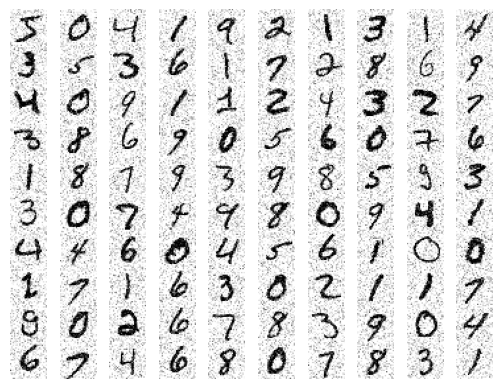

In [ ]:
plot_first_100(X_train_noisy)

`images + noise` is `float64`, because the noise is: no overflow this time. But some values fall below 0 or above 255, and `astype(np.uint8)` doesn't saturate them: converting an out-of-range float to an integer type gives platform-dependent garbage. So `np.clip` comes first. A seeded generator makes the result reproducible.

**15.** Write `binarize_image(image, threshold)`, which returns 1 where a pixel is greater than `threshold` and 0 elsewhere, as `uint8`. It must work for one image and for a whole array of images. Create `X_train_binarized` with threshold 128 and plot the first 100 images.

In [ ]:
def binarize_image(image: np.ndarray, threshold: int) -> np.ndarray:
    return (image > threshold).astype(np.uint8)


X_train_binarized = binarize_image(X_train, threshold=128)

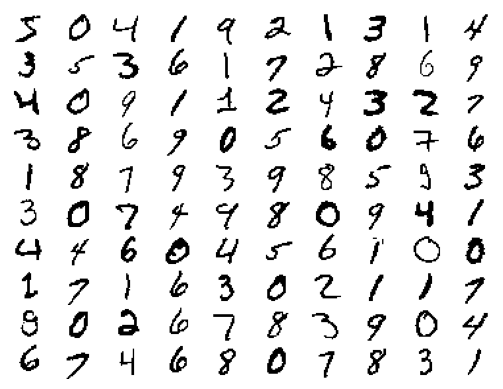

In [ ]:
plot_first_100(X_train_binarized)

`image > threshold` is a boolean array of the same shape as `image`, whatever its number of dimensions: no loop, and no special case for many images.

**16.** Plot the first 100 training images binarised with thresholds 80 and 180, one cell each. What changes?

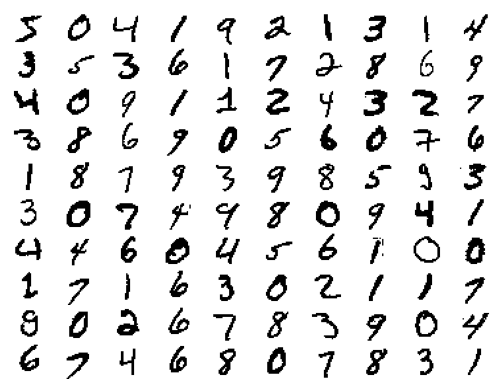

In [ ]:
plot_first_100(binarize_image(X_train, threshold=80))

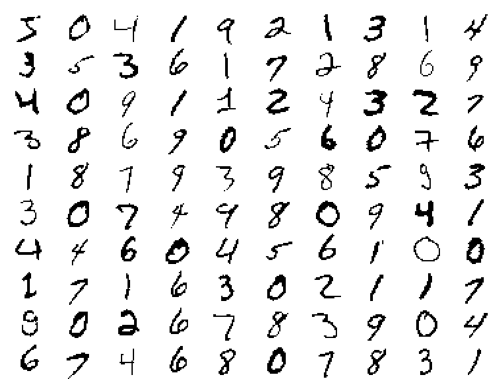

In [ ]:
plot_first_100(binarize_image(X_train, threshold=180))

A low threshold keeps the grey edges and gives thicker strokes. A high one keeps only the core of each stroke, and thin digits start to break.

**17.** Create `X_train_noisy_binarized` by binarising the noisy images with threshold 128, and plot the first 100. Try other thresholds: which one removes most of the noise without breaking the digits?

In [ ]:
X_train_noisy_binarized = binarize_image(X_train_noisy, threshold=128)

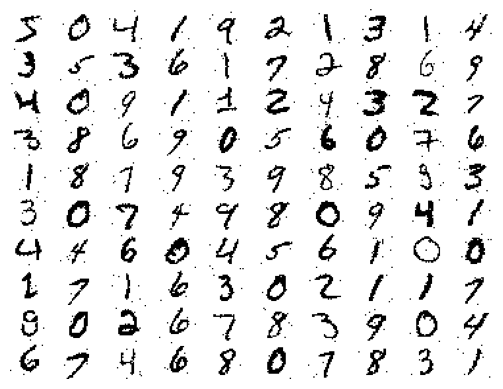

In [ ]:
plot_first_100(X_train_noisy_binarized)

With a standard deviation of 50, a background pixel exceeds 128 only when its noise is above 2.56 σ, which happens to about 0.5% of pixels: a few isolated dots per image. A higher threshold removes more of them, but also more of the strokes.

**18.** Write `shift_image(image, dx, dy)`, which moves an image `dx` pixels to the right (to the left if negative) and `dy` pixels down (up if negative), filling the space left behind with 0. Plot the first image shifted 10 pixels in each of the four directions, one cell each.

In [ ]:
def shift_image(image: np.ndarray, dx: int, dy: int) -> np.ndarray:
    height, width = image.shape
    shifted = np.zeros_like(image)
    destination_rows = slice(max(dy, 0), height + min(dy, 0))
    destination_cols = slice(max(dx, 0), width + min(dx, 0))
    source_rows = slice(max(-dy, 0), height + min(-dy, 0))
    source_cols = slice(max(-dx, 0), width + min(-dx, 0))
    shifted[destination_rows, destination_cols] = image[source_rows, source_cols]
    return shifted

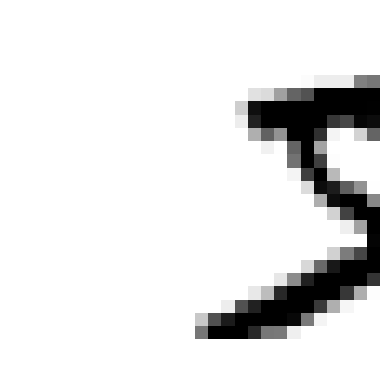

In [ ]:
plot_image(shift_image(X_train[0], dx=10, dy=0))

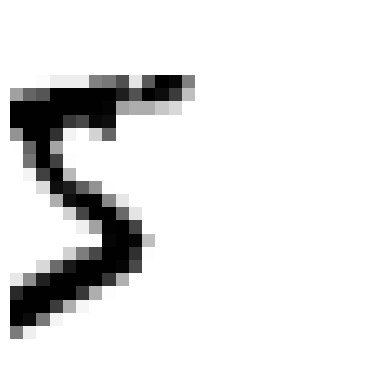

In [ ]:
plot_image(shift_image(X_train[0], dx=-10, dy=0))

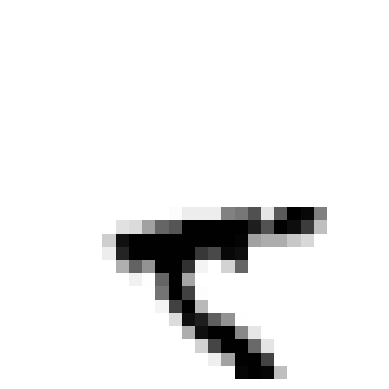

In [ ]:
plot_image(shift_image(X_train[0], dx=0, dy=10))

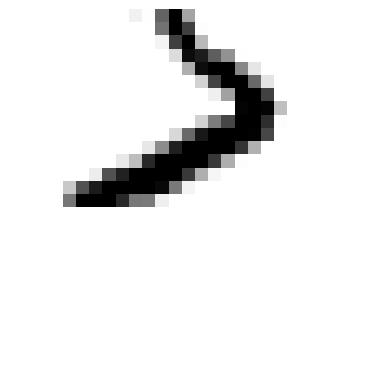

In [ ]:
plot_image(shift_image(X_train[0], dx=0, dy=-10))

The part of the image that stays in the frame is copied with two slices; everything else stays 0. `np.roll` looks tempting, but it moves the pixels that leave one side back in through the other:

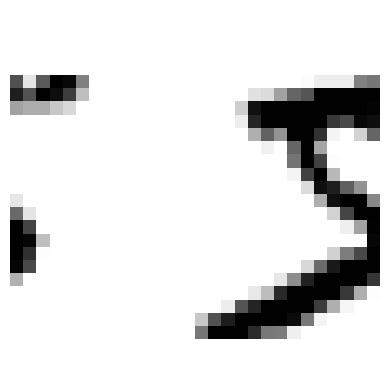

In [ ]:
plot_image(np.roll(X_train[0], 10, axis=1))

Fine for a periodic signal, wrong for an image.

**19.** Create `X_train_shifted_right_10` with every training image shifted 10 pixels to the right, and plot the first 100. Some digits are cut: which ones, and why?

In [ ]:
X_train_shifted_right_10 = np.array([shift_image(image, dx=10, dy=0) for image in X_train])

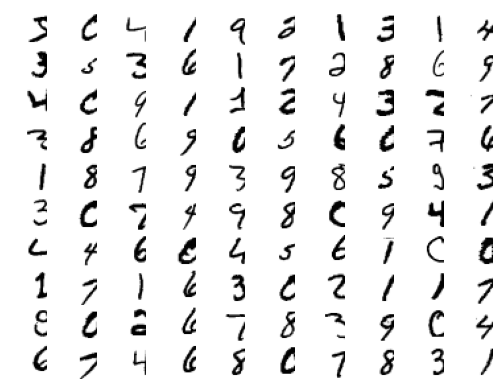

In [ ]:
plot_first_100(X_train_shifted_right_10)

When every image moves by the same amount, slicing the whole array does it without a Python loop:

In [ ]:
shifted_by_slicing = np.zeros_like(X_train)
shifted_by_slicing[:, :, 10:] = X_train[:, :, :-10]
np.array_equal(shifted_by_slicing, X_train_shifted_right_10)

True

A digit is cut when its ink reaches beyond column 17: 10 pixels more take it past column 27, the last one.

**20.** Write `find_limits(image)`, which returns `(top, bottom, left, right)`: the first and last rows and columns that contain ink. Check that the first training image gives `(5, 24, 4, 23)`. Then plot it with its limits drawn as lines (`plt.axhline` and `plt.axvline`).

In [ ]:
def find_limits(image: np.ndarray) -> tuple[int, int, int, int]:
    rows_with_ink = np.flatnonzero(image.any(axis=1))
    cols_with_ink = np.flatnonzero(image.any(axis=0))
    return int(rows_with_ink[0]), int(rows_with_ink[-1]), int(cols_with_ink[0]), int(cols_with_ink[-1])


find_limits(X_train[0])

(5, 24, 4, 23)

Another correct version lists the coordinates of every ink pixel and takes their extremes:

In [ ]:
def find_limits_from_pixels(image: np.ndarray) -> tuple[int, int, int, int]:
    rows, cols = np.nonzero(image)
    return int(rows.min()), int(rows.max()), int(cols.min()), int(cols.max())


find_limits_from_pixels(X_train[0])

(5, 24, 4, 23)

The first reduces the image to 28 booleans per axis before searching; the second builds the coordinates of about 150 ink pixels. Both fail on an image with no ink at all, which MNIST doesn't have.

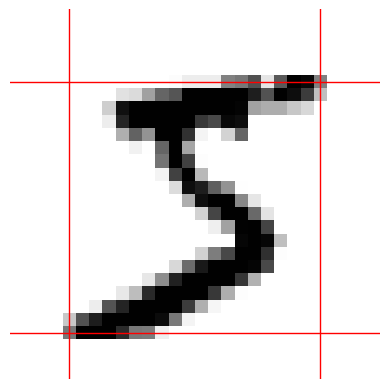

In [ ]:
def plot_with_limits(image: np.ndarray) -> None:
    top, bottom, left, right = find_limits(image)
    plt.imshow(image, cmap="binary")
    for row in (top, bottom):
        plt.axhline(row, color="red", linewidth=1)
    for col in (left, right):
        plt.axvline(col, color="red", linewidth=1)
    plt.axis("off")
    plt.show()


plot_with_limits(X_train[0])

**21.** Write `crop_image_limits(image)`, which returns the image cropped to its limits. What shape is the first training image once cropped, and why? Remember how MNIST was built.

In [ ]:
def crop_image_limits(image: np.ndarray) -> np.ndarray:
    top, bottom, left, right = find_limits(image)
    return image[top:bottom + 1, left:right + 1]


crop_image_limits(X_train[0]).shape

(20, 20)

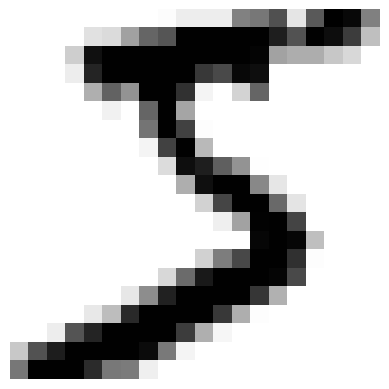

In [ ]:
plot_image(crop_image_limits(X_train[0]))

20×20: the box the digits were scaled into. `bottom` and `right` are the last row and column *with* ink, so the slices need `+ 1` to include them. Most digits are taller than wide, and then only their height is 20: across the training set, the longer side of the crop is 20 pixels in all but 13 of the 60,000 images.

**22.** Create `X_train_shifted`: every training image shifted by a random amount in each direction, but never so far that ink leaves the frame. Use `find_limits` to know how far each digit can move.

In [ ]:
def random_shift(image: np.ndarray) -> np.ndarray:
    height, width = image.shape
    top, bottom, left, right = find_limits(image)
    dy = rng.integers(-top, height - bottom)
    dx = rng.integers(-left, width - right)
    return shift_image(image, dx=dx, dy=dy)


X_train_shifted = np.array([random_shift(image) for image in X_train])

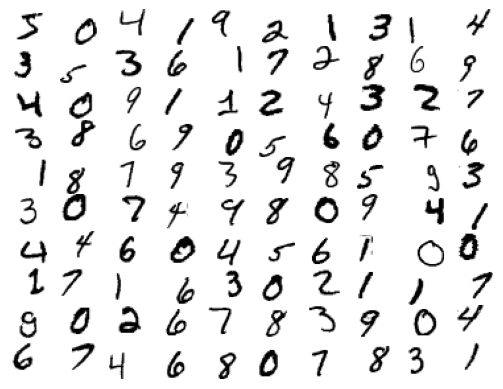

In [ ]:
plot_first_100(X_train_shifted)

`rng.integers` excludes its upper limit, so `dy` goes from `-top` (up to the first row) to `height - 1 - bottom` (down to the last one). The call passes `dx` and `dy` by keyword: swapping two offsets gives images that look valid and raise no error, the worst kind of bug. The tests check the rule in another way: if no ink leaves the frame, every shifted image has as much ink as the original.

**23.** Create `X_train_augmented` by joining, in this order, the original training images, the noisy ones, the binarised ones, the noisy and binarised ones, and the randomly shifted ones. Scale the two binarised sets back to 0 and 255 first, so that all the images share one range. Create `y_train_augmented` with the matching labels. How many images are there?

In [ ]:
X_train_augmented = np.concatenate([
    X_train,
    X_train_noisy,
    X_train_binarized * 255,
    X_train_noisy_binarized * 255,
    X_train_shifted,
])
y_train_augmented = np.tile(y_train, 5)
X_train_augmented.shape, y_train_augmented.shape

((300000, 28, 28), (300000,))

Five times the original: 300,000 images. Without the scaling, the binarised images would hold 0 and 1 among images that go up to 255, and they would look almost blank to a model. `np.tile` repeats the whole label array five times, in the order of the blocks; `np.repeat` would repeat each label five times in a row, which doesn't match.

### Going further

**24.** *(Optional, no test.)* Building `X_train_shifted` calls a Python function 60,000 times. Write a version without a loop over the images, and measure the speed-up. Is it worth it? Hint: pad the whole array with zeros once, then take for each image the 28×28 window that matches its offset, with fancy indexing.

In [ ]:
def random_shift_all(images: np.ndarray) -> np.ndarray:
    count, height, width = images.shape
    rows_with_ink = images.any(axis=2)
    cols_with_ink = images.any(axis=1)
    top = rows_with_ink.argmax(axis=1)
    bottom = height - 1 - rows_with_ink[:, ::-1].argmax(axis=1)
    left = cols_with_ink.argmax(axis=1)
    right = width - 1 - cols_with_ink[:, ::-1].argmax(axis=1)
    dy = rng.integers(-top, height - bottom)
    dx = rng.integers(-left, width - right)
    padded = np.pad(images, ((0, 0), (height, height), (width, width)))
    rows = height - dy[:, None] + np.arange(height)
    cols = width - dx[:, None] + np.arange(width)
    return padded[np.arange(count)[:, None, None], rows[:, :, None], cols[:, None, :]]

`argmax` on a boolean array returns the first `True`, so it finds the first row with ink in every image at once, and on the reversed array the last one. Pixel `(r, c)` of a shifted image comes from pixel `(r - dy, c - dx)` of the original, which is `(r - dy + 28, c - dx + 28)` in the padded array; the padding supplies the zeros. Shifting keeps all the ink in the frame:

In [ ]:
shifted_all = random_shift_all(X_train)
np.array_equal(shifted_all.sum(axis=(1, 2)), X_train.sum(axis=(1, 2)))

True

In [ ]:
start = time.perf_counter()
np.array([random_shift(image) for image in X_train[:10_000]])
loop_seconds = time.perf_counter() - start

start = time.perf_counter()
random_shift_all(X_train[:10_000])
vectorized_seconds = time.perf_counter() - start

loop_seconds / vectorized_seconds

1.9943441736923508

Only about twice as fast. Each call of `random_shift` already moves whole rows and columns with slicing, so the loop runs 10,000 times, not 7.8 million; the fancy indexing, in turn, computes an address for every pixel. Vectorising pays off most when it replaces a loop over single elements, as in exercise 13. Here it buys a small gain for code that is much harder to read and to get right: the loop over `random_shift` states the idea, and the fancy indexing hides it. Measure before you optimise. In practice, libraries such as torchvision do augmentation for you.